In [1]:
# ================================================================
# CELL 1: Mount Google Drive
# ================================================================

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# ================================================================
# CELL 2: Extract Dataset and Install
# ================================================================

import zipfile
import os

zip_path = "/content/drive/MyDrive/Research/dataset/dataset_500/dataset.zip"
extract_path = "/content/data/dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

DATASET_PATH = "/content/data/dataset"

for root, dirs, files in os.walk(extract_path):
    for d in dirs:
        subfolder = os.path.join(root, d)
        if any(f.endswith('.tif') for f in os.listdir(subfolder)):
            DATASET_PATH = root
            break

print(f"Dataset path: {DATASET_PATH}")
print(f"Classes: {sorted(os.listdir(DATASET_PATH))}")

!pip install rasterio opencv-python cma

Dataset path: /content/data/dataset
Classes: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 328.3/328.3 kB 10.8 MB/s eta 0:00:00


In [3]:
# ================================================================
# CELL 3: Imports
# ================================================================

import os
import gc
import json
import pickle
import numpy as np
import rasterio
import cv2
import cma
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt

tf.get_logger().setLevel('ERROR')

SAVE_DIR = "/content/drive/MyDrive/Research/cmaes_results/multispectral_13band_5000"
MASTER_RESULTS_FILE = "/content/drive/MyDrive/Research/all_experiment_results/master_results.json"
CHECKPOINT_PATH = os.path.join(SAVE_DIR, "cma_checkpoint.pkl")
os.makedirs(SAVE_DIR, exist_ok=True)

print("All imports done!")

All imports done!


In [4]:
# ================================================================
# CELL 4: Load Dataset (13-band, 5000 images)
# ================================================================

IMG_SIZE = 64

def load_13band_image(tif_path):
    with rasterio.open(tif_path) as src:
        if src.count < 13:
            raise ValueError(f"{tif_path} has {src.count} bands, expected 13.")
        img = src.read(list(range(1, 14))).astype(np.float32)
    img = np.transpose(img, (1, 2, 0))
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_LINEAR)
    img = img / 10000.0
    return img

X = []
y = []

class_names = sorted(os.listdir(DATASET_PATH))
class_to_idx = {name: idx for idx, name in enumerate(class_names)}

print("Class mapping:")
for k, v in class_to_idx.items():
    print(f"  {k} → {v}")

for class_name in class_names:
    class_folder = os.path.join(DATASET_PATH, class_name)
    if not os.path.isdir(class_folder):
        continue
    label = class_to_idx[class_name]
    for file in os.listdir(class_folder):
        if file.endswith(".tif"):
            img_path = os.path.join(class_folder, file)
            img = load_13band_image(img_path)
            X.append(img)
            y.append(label)

X = np.array(X, dtype=np.float32)
y = np.array(y, dtype=np.int32)

print(f"\nDataset: X={X.shape}, y={y.shape}")

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

del X, y, X_temp, y_temp
gc.collect()

# Convert to float16 to save RAM
X_train = X_train.astype(np.float16)
X_val = X_val.astype(np.float16)
X_test = X_test.astype(np.float16)

print(f"Train: {X_train.shape}")
print(f"Validation: {X_val.shape}")
print(f"Test: {X_test.shape}")

Class mapping:
  AnnualCrop → 0
  Forest → 1
  HerbaceousVegetation → 2
  Highway → 3
  Industrial → 4
  Pasture → 5
  PermanentCrop → 6
  Residential → 7
  River → 8
  SeaLake → 9

Dataset: X=(5000, 64, 64, 13), y=(5000,)
Train: (3500, 64, 64, 13)
Validation: (750, 64, 64, 13)
Test: (750, 64, 64, 13)


In [5]:
# ================================================================
# CELL 5: Model Building Function
# ================================================================

activation_map = {
    0: "relu",
    1: "tanh"
}

def build_cnn_model(
    input_shape,
    num_classes,
    num_conv_layers,
    filters_list,
    kernel_size,
    activation,
    dropout_rate
):
    model = models.Sequential()
    model.add(layers.Input(shape=input_shape))

    for i in range(num_conv_layers):
        model.add(
            layers.Conv2D(
                filters=filters_list[i],
                kernel_size=(kernel_size, kernel_size),
                padding="same",
                activation=activation
            )
        )
        model.add(layers.MaxPooling2D(pool_size=(2, 2)))

    model.add(layers.Flatten())
    model.add(layers.Dense(128, activation=activation))
    model.add(layers.Dropout(dropout_rate))
    model.add(layers.Dense(num_classes, activation="softmax"))

    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

print("Model building function ready!")

Model building function ready!


In [6]:
# ================================================================
# CELL 6: CMA-ES Search Space and Decode Function
# ================================================================

BOUNDS = {
    "num_conv_layers": (1, 3),
    "filters_1": (16, 64),
    "filters_2": (32, 128),
    "filters_3": (64, 256),
    "kernel_size": (3, 5),
    "activation_id": (0, 1),
    "dropout_rate": (0.0, 0.5)
}

def decode_architecture(x):
    num_conv_layers = int(np.clip(round(x[0]), *BOUNDS["num_conv_layers"]))
    filters_1 = int(np.clip(round(x[1]), *BOUNDS["filters_1"]))
    filters_2 = int(np.clip(round(x[2]), *BOUNDS["filters_2"]))
    filters_3 = int(np.clip(round(x[3]), *BOUNDS["filters_3"]))
    kernel_size = int(np.clip(round(x[4]), *BOUNDS["kernel_size"]))
    activation_id = int(np.clip(round(x[5]), *BOUNDS["activation_id"]))
    activation = activation_map[activation_id]
    dropout_rate = float(np.clip(x[6], *BOUNDS["dropout_rate"]))

    filters_list = [filters_1]
    if num_conv_layers > 1:
        filters_list.append(filters_2)
    if num_conv_layers > 2:
        filters_list.append(filters_3)

    return {
        "num_conv_layers": num_conv_layers,
        "filters_list": filters_list,
        "kernel_size": kernel_size,
        "activation": activation,
        "dropout_rate": dropout_rate
    }

print("Search space ready!")

Search space ready!


In [7]:
# ================================================================
# CELL 7: CMA-ES Search WITH CHECKPOINT/RESUME
#
# After it finishes 5 generations:
#   1. It will print "⚠️  NOW DO THIS:"
#   2. Go to Runtime → Restart runtime
#   3. Run ALL cells from Cell 1 to Cell 7 again
#   4. It will auto-resume from where it stopped
#   5. Repeat until all 10 generations are done
# ================================================================

# --- SETTINGS ---
TOTAL_GENERATIONS = 10
GENS_PER_CHUNK = 5
POPSIZE = 20
EPOCHS_PER_CANDIDATE = 10

x0 = [3, 32, 64, 128, 3, 0, 0.5]
sigma = 0.5

# --- LOAD OR CREATE CMA-ES STATE ---
if os.path.exists(CHECKPOINT_PATH):
    print("📂 Loading checkpoint...")
    with open(CHECKPOINT_PATH, 'rb') as f:
        checkpoint = pickle.load(f)

    es = checkpoint['es']
    best_val_accuracy = checkpoint['best_val_accuracy']
    best_architecture = checkpoint['best_architecture']
    completed_generations = checkpoint['completed_generations']
    all_search_results = checkpoint['all_search_results']
    print(f"✅ Resuming from generation {completed_generations + 1}")
    print(f"🏆 Best so far: {best_val_accuracy:.4f}")
else:
    print("🆕 Starting fresh CMA-ES search (13-band, 5000 images)...")
    es = cma.CMAEvolutionStrategy(x0, sigma, {
        "popsize": POPSIZE,
        "verb_log": 0
    })
    best_val_accuracy = 0.0
    best_architecture = None
    completed_generations = 0
    all_search_results = []

# --- FITNESS FUNCTION ---
def fitness_function(x):
    global best_val_accuracy, best_architecture, all_search_results

    tf.keras.backend.clear_session()
    gc.collect()

    arch = decode_architecture(x)

    print(f"  Layers: {arch['num_conv_layers']}, Filters: {arch['filters_list']}, "
          f"Kernel: {arch['kernel_size']}, Act: {arch['activation']}, "
          f"Drop: {arch['dropout_rate']:.2f}")

    model = build_cnn_model(
        input_shape=(64, 64, 13),
        num_classes=10,
        num_conv_layers=arch["num_conv_layers"],
        filters_list=arch["filters_list"],
        kernel_size=arch["kernel_size"],
        activation=arch["activation"],
        dropout_rate=arch["dropout_rate"]
    )

    model.fit(
        X_train, y_train,
        epochs=EPOCHS_PER_CANDIDATE,
        batch_size=32,
        validation_data=(X_val, y_val),
        verbose=0
    )

    val_loss, val_acc = model.evaluate(X_val, y_val, verbose=0)
    print(f"  Val Accuracy: {val_acc:.4f}")

    if val_acc > best_val_accuracy:
        best_val_accuracy = float(val_acc)
        best_architecture = {
            'num_conv_layers': arch['num_conv_layers'],
            'filters_list': arch['filters_list'],
            'kernel_size': arch['kernel_size'],
            'activation': arch['activation'],
            'dropout_rate': arch['dropout_rate']
        }
        try:
            model.save(os.path.join(SAVE_DIR, 'best_model_search.h5'))
            print(f"  💾 New best! Saved.")
        except Exception as e:
            print(f"  Could not save: {e}")

    fitness = 1.0 - val_acc

    all_search_results.append({
        'generation': completed_generations + 1,
        'architecture': arch,
        'val_acc': float(val_acc)
    })

    del model
    gc.collect()

    return fitness

# --- RUN GENERATIONS ---
remaining = TOTAL_GENERATIONS - completed_generations
gens_to_run = min(GENS_PER_CHUNK, remaining)

if gens_to_run <= 0:
    print(f"\n🏁 ALL {TOTAL_GENERATIONS} GENERATIONS ALREADY COMPLETED!")
    print(f"🏆 Best Validation Accuracy: {best_val_accuracy:.4f}")
    if best_architecture:
        for k, v in best_architecture.items():
            print(f"   {k}: {v}")
else:
    print(f"\n🚀 Running generations {completed_generations+1} to {completed_generations+gens_to_run} out of {TOTAL_GENERATIONS}")

    for g in range(gens_to_run):
        gen_num = completed_generations + g + 1
        print(f"\n{'='*50}")
        print(f"  Generation {gen_num}/{TOTAL_GENERATIONS}")
        print(f"{'='*50}")

        solutions = es.ask()
        fitnesses = []

        for i, x in enumerate(solutions):
            print(f"\n--- Candidate {i+1}/{POPSIZE} (Gen {gen_num}) ---")
            f = fitness_function(x)
            fitnesses.append(f)

        es.tell(solutions, fitnesses)
        es.disp()
        print(f"\n🏆 Best after Gen {gen_num}: {best_val_accuracy:.4f}")

    completed_generations += gens_to_run

    # --- SAVE CHECKPOINT ---
    checkpoint = {
        'es': es,
        'best_val_accuracy': best_val_accuracy,
        'best_architecture': best_architecture,
        'completed_generations': completed_generations,
        'all_search_results': all_search_results
    }
    with open(CHECKPOINT_PATH, 'wb') as f:
        pickle.dump(checkpoint, f)

    print(f"\n{'='*50}")
    print(f"💾 CHECKPOINT SAVED!")
    print(f"   Completed: {completed_generations}/{TOTAL_GENERATIONS} generations")
    print(f"   Best accuracy: {best_val_accuracy:.4f}")
    if best_architecture:
        for k, v in best_architecture.items():
            print(f"   {k}: {v}")
    print(f"{'='*50}")

    if completed_generations < TOTAL_GENERATIONS:
        print(f"\n⚠️  NOW DO THIS:")
        print(f"   1. Go to Runtime → Restart runtime")
        print(f"   2. Run ALL cells again (Cell 1 through Cell 7)")
        print(f"   3. It will auto-resume from generation {completed_generations+1}")
        print(f"   4. Repeat until all {TOTAL_GENERATIONS} generations are done")
    else:
        print(f"\n🏁 ALL {TOTAL_GENERATIONS} GENERATIONS COMPLETE!")

# Save search results
search_data = {
    'config': '13-band Multispectral, 5000 images',
    'generations': TOTAL_GENERATIONS,
    'population': POPSIZE,
    'epochs_per_candidate': EPOCHS_PER_CANDIDATE,
    'completed_generations': completed_generations,
    'best_val_accuracy': best_val_accuracy,
    'best_architecture': best_architecture,
    'all_results': all_search_results
}
with open(os.path.join(SAVE_DIR, 'search_results.json'), 'w') as f:
    json.dump(search_data, f, indent=2)

📂 Loading checkpoint...
✅ Resuming from generation 6
🏆 Best so far: 0.8707

🚀 Running generations 6 to 10 out of 10

  Generation 6/10

--- Candidate 1/20 (Gen 6) ---
  Layers: 3, Filters: [31, 65, 127], Kernel: 3, Act: tanh, Drop: 0.44
  Val Accuracy: 0.8373

--- Candidate 2/20 (Gen 6) ---
  Layers: 3, Filters: [33, 63, 128], Kernel: 3, Act: relu, Drop: 0.00
  Val Accuracy: 0.8520

--- Candidate 3/20 (Gen 6) ---
  Layers: 3, Filters: [32, 63, 127], Kernel: 3, Act: tanh, Drop: 0.50
  Val Accuracy: 0.8613

--- Candidate 4/20 (Gen 6) ---
  Layers: 3, Filters: [32, 64, 128], Kernel: 3, Act: tanh, Drop: 0.30


  Val Accuracy: 0.8773
  💾 New best! Saved.

--- Candidate 5/20 (Gen 6) ---
  Layers: 3, Filters: [31, 63, 126], Kernel: 3, Act: tanh, Drop: 0.50
  Val Accuracy: 0.8747

--- Candidate 6/20 (Gen 6) ---
  Layers: 3, Filters: [32, 63, 126], Kernel: 3, Act: tanh, Drop: 0.50


  Val Accuracy: 0.8800
  💾 New best! Saved.

--- Candidate 7/20 (Gen 6) ---
  Layers: 3, Filters: [32, 64, 129], Kernel: 3, Act: relu, Drop: 0.50
  Val Accuracy: 0.8227

--- Candidate 8/20 (Gen 6) ---
  Layers: 3, Filters: [31, 63, 128], Kernel: 3, Act: tanh, Drop: 0.25
  Val Accuracy: 0.8680

--- Candidate 9/20 (Gen 6) ---
  Layers: 3, Filters: [32, 64, 126], Kernel: 3, Act: tanh, Drop: 0.50
  Val Accuracy: 0.8600

--- Candidate 10/20 (Gen 6) ---
  Layers: 3, Filters: [32, 65, 126], Kernel: 3, Act: tanh, Drop: 0.00
  Val Accuracy: 0.8560

--- Candidate 11/20 (Gen 6) ---
  Layers: 3, Filters: [32, 64, 126], Kernel: 3, Act: tanh, Drop: 0.50
  Val Accuracy: 0.8627

--- Candidate 12/20 (Gen 6) ---
  Layers: 3, Filters: [33, 64, 127], Kernel: 3, Act: tanh, Drop: 0.20
  Val Accuracy: 0.8493

--- Candidate 13/20 (Gen 6) ---
  Layers: 3, Filters: [32, 64, 127], Kernel: 3, Act: tanh, Drop: 0.50
  Val Accuracy: 0.8067

--- Candidate 14/20 (Gen 6) ---
  Layers: 3, Filters: [33, 65, 128], Kernel:

  Val Accuracy: 0.8893
  💾 New best! Saved.

--- Candidate 4/20 (Gen 7) ---
  Layers: 3, Filters: [32, 63, 126], Kernel: 3, Act: tanh, Drop: 0.50


  Val Accuracy: 0.8920
  💾 New best! Saved.

--- Candidate 5/20 (Gen 7) ---
  Layers: 3, Filters: [31, 64, 126], Kernel: 3, Act: tanh, Drop: 0.22
  Val Accuracy: 0.8560

--- Candidate 6/20 (Gen 7) ---
  Layers: 3, Filters: [34, 63, 130], Kernel: 3, Act: tanh, Drop: 0.09
  Val Accuracy: 0.8520

--- Candidate 7/20 (Gen 7) ---
  Layers: 3, Filters: [33, 63, 126], Kernel: 4, Act: tanh, Drop: 0.50
  Val Accuracy: 0.8653

--- Candidate 8/20 (Gen 7) ---
  Layers: 3, Filters: [31, 63, 127], Kernel: 3, Act: tanh, Drop: 0.50
  Val Accuracy: 0.8560

--- Candidate 9/20 (Gen 7) ---
  Layers: 3, Filters: [33, 64, 127], Kernel: 3, Act: tanh, Drop: 0.19
  Val Accuracy: 0.8467

--- Candidate 10/20 (Gen 7) ---
  Layers: 3, Filters: [32, 63, 127], Kernel: 3, Act: tanh, Drop: 0.00
  Val Accuracy: 0.8733

--- Candidate 11/20 (Gen 7) ---
  Layers: 3, Filters: [32, 63, 128], Kernel: 3, Act: tanh, Drop: 0.50
  Val Accuracy: 0.8693

--- Candidate 12/20 (Gen 7) ---
  Layers: 3, Filters: [31, 62, 127], Kernel: 3

In [8]:
# ================================================================
# CELL 8: Retrain Best CMA-ES Architecture (100 epochs)
# ⚠️ ONLY RUN THIS AFTER ALL 10 GENERATIONS ARE COMPLETE
# ================================================================

print("=" * 60)
print("  RETRAINING BEST CMA-ES ARCHITECTURE (100 epochs)")
print("  Config: 13-band Multispectral, 5000 images")
print("=" * 60)

tf.keras.backend.clear_session()
gc.collect()

if best_architecture is None:
    with open(os.path.join(SAVE_DIR, 'search_results.json'), 'r') as f:
        search_data = json.load(f)
    best_architecture = search_data['best_architecture']
    best_val_accuracy = search_data['best_val_accuracy']

print(f"Architecture: {best_architecture}")

cmaes_model = build_cnn_model(
    input_shape=(64, 64, 13),
    num_classes=10,
    num_conv_layers=best_architecture['num_conv_layers'],
    filters_list=best_architecture['filters_list'],
    kernel_size=best_architecture['kernel_size'],
    activation=best_architecture['activation'],
    dropout_rate=best_architecture['dropout_rate']
)

cmaes_model.summary()

my_callbacks = [
    callbacks.EarlyStopping(
        monitor='val_loss', patience=10,
        restore_best_weights=True, verbose=1
    ),
    callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5,
        patience=5, min_lr=1e-6, verbose=1
    )
]

history_cmaes = cmaes_model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=my_callbacks,
    verbose=1
)

cmaes_val_loss, cmaes_val_acc = cmaes_model.evaluate(X_val, y_val, verbose=0)
cmaes_test_loss, cmaes_test_acc = cmaes_model.evaluate(X_test, y_test, verbose=0)

print(f"\n📊 CMA-ES Validation Accuracy: {cmaes_val_acc:.4f}")
print(f"📊 CMA-ES Test Accuracy:       {cmaes_test_acc:.4f}")

y_pred_cmaes = np.argmax(cmaes_model.predict(X_test), axis=1)

cmaes_model.save(os.path.join(SAVE_DIR, 'cmaes_retrained_model.h5'))

cmaes_history = {
    'accuracy': [float(x) for x in history_cmaes.history['accuracy']],
    'val_accuracy': [float(x) for x in history_cmaes.history['val_accuracy']],
    'loss': [float(x) for x in history_cmaes.history['loss']],
    'val_loss': [float(x) for x in history_cmaes.history['val_loss']],
}
with open(os.path.join(SAVE_DIR, 'cmaes_training_history.json'), 'w') as f:
    json.dump(cmaes_history, f)

cmaes_report = classification_report(
    y_test, y_pred_cmaes,
    target_names=class_names,
    digits=4,
    output_dict=True
)

del cmaes_model
gc.collect()

print("✅ CMA-ES retraining complete!")

  RETRAINING BEST CMA-ES ARCHITECTURE (100 epochs)
  Config: 13-band Multispectral, 5000 images
Architecture: {'num_conv_layers': 3, 'filters_list': [32, 63, 126], 'kernel_size': 3, 'activation': 'tanh', 'dropout_rate': 0.5}


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │         3,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 63)     │        18,207 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 63)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 126)    │        71,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 126)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8064)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,032,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,127,161 (4.30 MB)

 Trainable params: 1,127,161 (4.30 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 9s 50ms/step - accuracy: 0.4983 - loss: 1.3605 - val_accuracy: 0.6773 - val_loss: 0.9009 - learning_rate: 0.0010
Epoch 2/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.6517 - loss: 0.9531 - val_accuracy: 0.6787 - val_loss: 0.8912 - learning_rate: 0.0010
Epoch 3/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.6806 - loss: 0.8950 - val_accuracy: 0.7560 - val_loss: 0.6399 - learning_rate: 0.0010
Epoch 4/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.7317 - loss: 0.7699 - val_accuracy: 0.7173 - val_loss: 0.7829 - learning_rate: 0.0010
Epoch 5/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.7829 - loss: 0.6149 - val_accuracy: 0.8187 - val_loss: 0.5082 - learning_rate: 0.0010
Epoch 6/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.8066 - loss: 0.5323 - val_accuracy: 0.7667 - val_loss: 0.6318 - learning_rate: 0.0010
Epoch 7/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.8471 - l

✅ CMA-ES retraining complete!


In [9]:
# ================================================================
# CELL 9: Load Baseline Results and Compare
# ================================================================

print("=" * 60)
print("  COMPARISON: BASELINE vs CMA-ES")
print("  Config: 13-band Multispectral, 5000 images")
print("=" * 60)

with open(MASTER_RESULTS_FILE, 'r') as f:
    master_data = json.load(f)

baseline_entry = next(
    (r for r in master_data['experiments']
     if r['num_bands'] == 13 and r['num_images'] == '5000'),
    None
)

if baseline_entry is None:
    print("❌ Baseline result for 13-band 5000 not found in master table!")
    print("   Run the baseline notebook first.")
else:
    baseline_val_acc = baseline_entry['val_accuracy']
    baseline_test_acc = baseline_entry['test_accuracy']
    baseline_f1 = baseline_entry['macro_f1']

    print("\nCMA-ES CNN Classification Report:")
    print(classification_report(y_test, y_pred_cmaes, target_names=class_names, digits=4))

    print(f"\n{'='*65}")
    print(f"{'Metric':<25} {'Baseline':>12} {'CMA-ES':>12} {'Difference':>12}")
    print("-" * 65)
    print(f"{'Validation Accuracy':<25} {baseline_val_acc:>12.4f} {cmaes_val_acc:>12.4f} {cmaes_val_acc - baseline_val_acc:>+12.4f}")
    print(f"{'Test Accuracy':<25} {baseline_test_acc:>12.4f} {cmaes_test_acc:>12.4f} {cmaes_test_acc - baseline_test_acc:>+12.4f}")
    print(f"{'Macro F1-Score':<25} {baseline_f1:>12.4f} {cmaes_report['macro avg']['f1-score']:>12.4f} {cmaes_report['macro avg']['f1-score'] - baseline_f1:>+12.4f}")
    print("-" * 65)

    if 'per_class_f1' in baseline_entry:
        print(f"\n{'Class':<20} {'Baseline F1':>12} {'CMA-ES F1':>12} {'Diff':>12}")
        print("-" * 56)
        for cls in class_names:
            b = baseline_entry['per_class_f1'].get(cls, 0)
            c = cmaes_report[cls]['f1-score']
            print(f"{cls:<20} {b:>12.4f} {c:>12.4f} {c - b:>+12.4f}")

    print(f"\n  Baseline architecture: 3 layers, [32,64,128], kernel 3, relu, dropout 0.5")
    print(f"  CMA-ES architecture:  {best_architecture['num_conv_layers']} layers, "
          f"{best_architecture['filters_list']}, kernel {best_architecture['kernel_size']}, "
          f"{best_architecture['activation']}, dropout {best_architecture['dropout_rate']:.2f}")

  COMPARISON: BASELINE vs CMA-ES
  Config: 13-band Multispectral, 5000 images

CMA-ES CNN Classification Report:
                      precision    recall  f1-score   support

          AnnualCrop     0.8286    0.7733    0.8000        75
              Forest     0.9595    0.9467    0.9530        75
HerbaceousVegetation     0.7500    0.8800    0.8098        75
             Highway     0.8358    0.7467    0.7887        75
          Industrial     0.8780    0.9600    0.9172        75
             Pasture     0.7791    0.8933    0.8323        75
       PermanentCrop     0.8788    0.7733    0.8227        75
         Residential     0.9296    0.8800    0.9041        75
               River     0.9577    0.9067    0.9315        75
             SeaLake     1.0000    1.0000    1.0000        75

            accuracy                         0.8760       750
           macro avg     0.8797    0.8760    0.8759       750
        weighted avg     0.8797    0.8760    0.8759       750


Metric         

In [10]:
# ================================================================
# CELL 10: Save to Master Results Table
# ================================================================

master_data['cmaes_experiments']['13-band_5000'] = {
    'val_accuracy': float(cmaes_val_acc),
    'test_accuracy': float(cmaes_test_acc),
    'macro_f1': float(cmaes_report['macro avg']['f1-score']),
    'architecture': best_architecture,
    'search_config': {
        'generations': TOTAL_GENERATIONS,
        'population': POPSIZE,
        'epochs_per_candidate': EPOCHS_PER_CANDIDATE,
        'total_evaluated': len(all_search_results)
    }
}

with open(MASTER_RESULTS_FILE, 'w') as f:
    json.dump(master_data, f, indent=2)

print(f"💾 CMA-ES results saved to master table!")

print(f"\n{'='*70}")
print("  MASTER TABLE STATUS — ALL EXPERIMENTS")
print(f"{'='*70}")
print(f"{'Configuration':<25} {'Baseline Test':>14} {'CMA-ES Test':>12} {'Improvement':>12} {'Status':>8}")
print("-" * 75)

cmaes_exps = master_data.get('cmaes_experiments', {})
for r in master_data.get('experiments', []):
    key = f"{r['num_bands']}-band_{r['num_images']}"
    cmaes = cmaes_exps.get(key, {})
    c_test = cmaes.get('test_accuracy')

    c_str = f"{c_test:.4f}" if c_test else "---"
    diff_str = f"{c_test - r['test_accuracy']:+.4f}" if c_test else "---"
    status = "✅" if c_test else "⏳"
    label = f"{r['num_bands']}-band, {r['num_images']} imgs"

    print(f"{label:<25} {r['test_accuracy']:>14.4f} {c_str:>12} {diff_str:>12} {status:>8}")

print("-" * 75)

all_done = all(
    cmaes_exps.get(f"{r['num_bands']}-band_{r['num_images']}", {}).get('test_accuracy') is not None
    for r in master_data.get('experiments', [])
)

if all_done:
    print("\n🏁 ALL 8 EXPERIMENTS COMPLETE! (4 baseline + 4 CMA-ES)")
    print("   You can now update your thesis with these final numbers.")

💾 CMA-ES results saved to master table!

  MASTER TABLE STATUS — ALL EXPERIMENTS
Configuration              Baseline Test  CMA-ES Test  Improvement   Status
---------------------------------------------------------------------------
3-band, 1000 imgs                 0.6800       0.6733      -0.0067        ✅
13-band, 1000 imgs                0.8267       0.7933      -0.0333        ✅
3-band, 5000 imgs                 0.8067       0.7813      -0.0253        ✅
13-band, 5000 imgs                0.8960       0.8760      -0.0200        ✅
---------------------------------------------------------------------------

🏁 ALL 8 EXPERIMENTS COMPLETE! (4 baseline + 4 CMA-ES)
   You can now update your thesis with these final numbers.


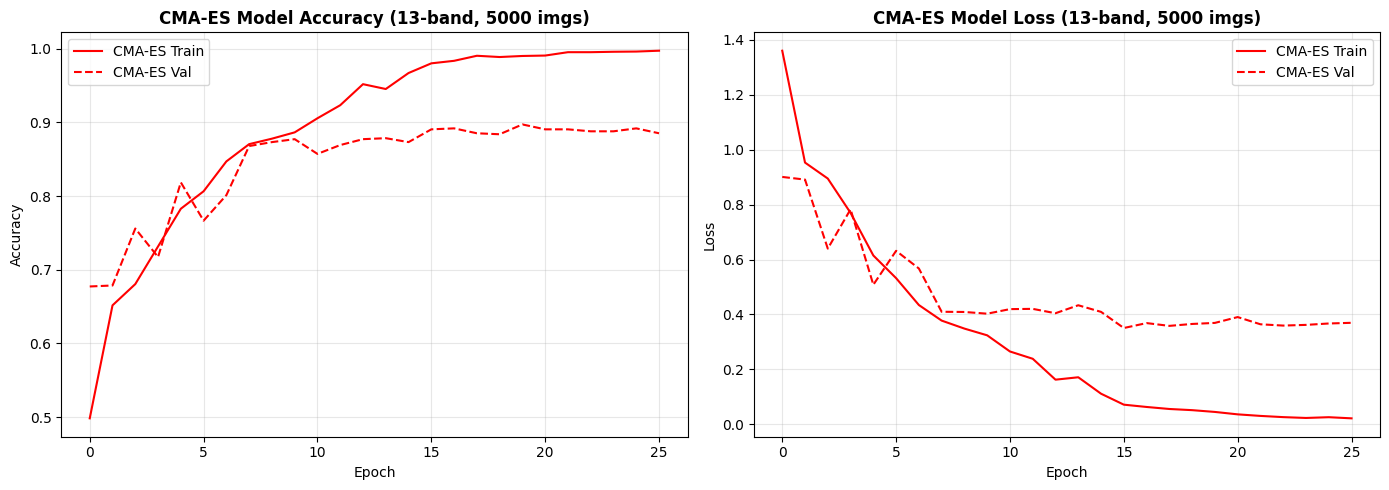

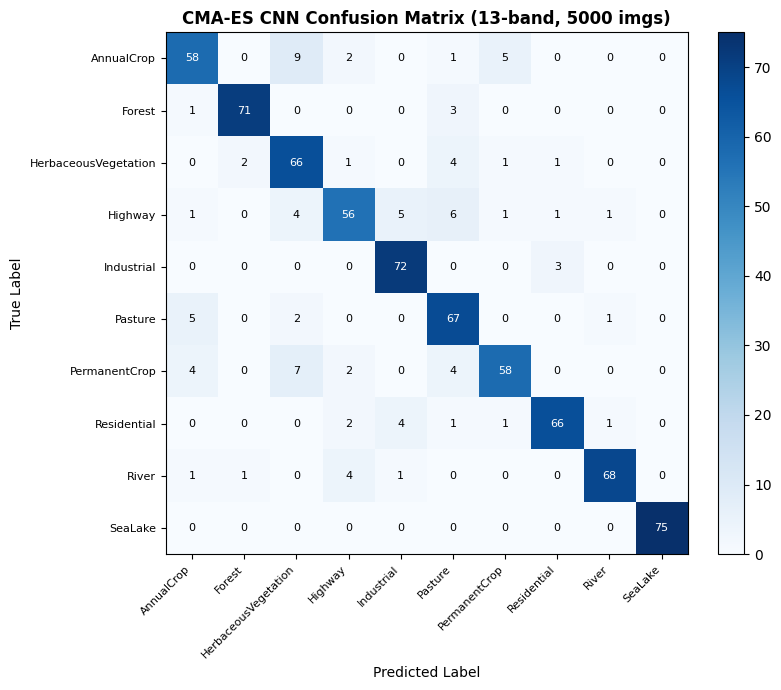

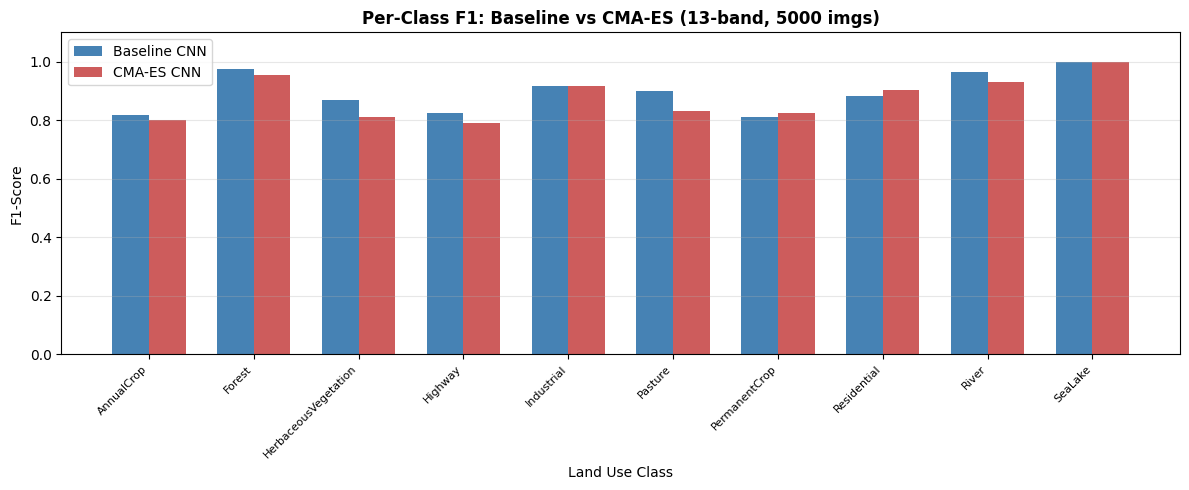

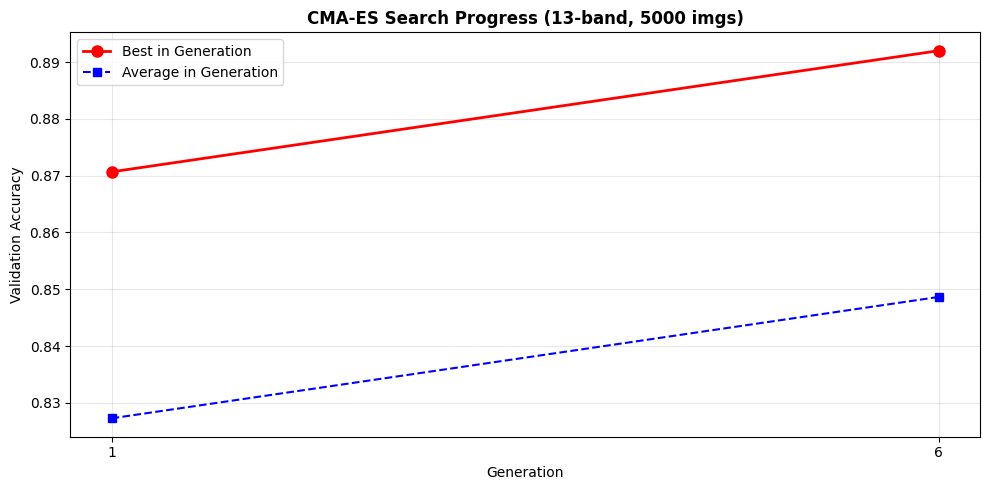


💾 All charts saved to /content/drive/MyDrive/Research/cmaes_results/multispectral_13band_5000


In [11]:
# ================================================================
# CELL 11: Generate Charts
# ================================================================

# ---- Training curves ----
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(cmaes_history['accuracy'], label='CMA-ES Train', linestyle='-', color='red')
axes[0].plot(cmaes_history['val_accuracy'], label='CMA-ES Val', linestyle='--', color='red')
axes[0].set_title('CMA-ES Model Accuracy (13-band, 5000 imgs)', fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(cmaes_history['loss'], label='CMA-ES Train', linestyle='-', color='red')
axes[1].plot(cmaes_history['val_loss'], label='CMA-ES Val', linestyle='--', color='red')
axes[1].set_title('CMA-ES Model Loss (13-band, 5000 imgs)', fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'training_curves.png'), dpi=200, bbox_inches='tight')
plt.show()

# ---- Confusion matrix ----
cm_cmaes = confusion_matrix(y_test, y_pred_cmaes)

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(cm_cmaes, interpolation='nearest', cmap=plt.cm.Blues)
ax.set_title('CMA-ES CNN Confusion Matrix (13-band, 5000 imgs)', fontweight='bold')
plt.colorbar(im, ax=ax, fraction=0.046)

thresh = cm_cmaes.max() / 2.0
for i in range(cm_cmaes.shape[0]):
    for j in range(cm_cmaes.shape[1]):
        ax.text(j, i, format(cm_cmaes[i, j], 'd'),
                ha="center", va="center",
                color="white" if cm_cmaes[i, j] > thresh else "black", fontsize=8)

ax.set_xticks(range(10))
ax.set_yticks(range(10))
ax.set_xticklabels(class_names, rotation=45, ha='right', fontsize=8)
ax.set_yticklabels(class_names, fontsize=8)
ax.set_ylabel('True Label')
ax.set_xlabel('Predicted Label')

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'confusion_matrix.png'), dpi=200, bbox_inches='tight')
plt.show()

# ---- Per-class F1 comparison ----
if baseline_entry and 'per_class_f1' in baseline_entry:
    fig, ax = plt.subplots(figsize=(12, 5))

    b_f1 = [baseline_entry['per_class_f1'].get(cls, 0) for cls in class_names]
    c_f1 = [cmaes_report[cls]['f1-score'] for cls in class_names]
    x = np.arange(len(class_names))
    width = 0.35

    ax.bar(x - width/2, b_f1, width, label='Baseline CNN', color='steelblue')
    ax.bar(x + width/2, c_f1, width, label='CMA-ES CNN', color='indianred')
    ax.set_xlabel('Land Use Class')
    ax.set_ylabel('F1-Score')
    ax.set_title('Per-Class F1: Baseline vs CMA-ES (13-band, 5000 imgs)', fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(class_names, rotation=45, ha='right', fontsize=8)
    ax.legend()
    ax.set_ylim(0, 1.1)
    ax.grid(True, axis='y', alpha=0.3)

    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_DIR, 'per_class_f1.png'), dpi=200, bbox_inches='tight')
    plt.show()

# ---- Search progress ----
fig, ax = plt.subplots(figsize=(10, 5))

gen_numbers = []
gen_best = []
gen_avg = []

for gen in range(1, completed_generations + 1):
    gen_results = [r for r in all_search_results if r['generation'] == gen]
    if gen_results:
        gen_numbers.append(gen)
        gen_best.append(max(r['val_acc'] for r in gen_results))
        gen_avg.append(np.mean([r['val_acc'] for r in gen_results]))

ax.plot(gen_numbers, gen_best, 'ro-', label='Best in Generation', linewidth=2, markersize=8)
ax.plot(gen_numbers, gen_avg, 'bs--', label='Average in Generation', linewidth=1.5, markersize=6)
ax.set_xlabel('Generation')
ax.set_ylabel('Validation Accuracy')
ax.set_title('CMA-ES Search Progress (13-band, 5000 imgs)', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xticks(gen_numbers)

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'search_progress.png'), dpi=200, bbox_inches='tight')
plt.show()

print(f"\n💾 All charts saved to {SAVE_DIR}")

In [12]:
# ================================================================
# CELL 12: Final Summary
# ================================================================

b_test = baseline_entry['test_accuracy'] if baseline_entry else 0
b_val = baseline_entry['val_accuracy'] if baseline_entry else 0

print("=" * 60)
print("  COMPLETE RESULTS SUMMARY")
print("  Experiment: CMA-ES, 13-band Multispectral, 5000 images")
print("=" * 60)

print(f"""
DATASET:
  Total images: 5,000 (500 per class)
  Training: {X_train.shape[0]}
  Validation: {X_val.shape[0]}
  Test: {X_test.shape[0]}
  Input shape: (64, 64, 13)
  Classes: 10

CMA-ES SEARCH:
  Generations: {TOTAL_GENERATIONS}
  Population: {POPSIZE}
  Epochs per candidate: {EPOCHS_PER_CANDIDATE}
  Architectures evaluated: {len(all_search_results)}
  Best architecture found:
    Layers: {best_architecture['num_conv_layers']}
    Filters: {best_architecture['filters_list']}
    Kernel: {best_architecture['kernel_size']}
    Activation: {best_architecture['activation']}
    Dropout: {best_architecture['dropout_rate']}

BASELINE CNN (from baseline notebook):
  Architecture: 3 layers, [32,64,128], kernel 3, relu, dropout=0.5
  Validation Accuracy: {b_val:.4f}
  Test Accuracy: {b_test:.4f}

CMA-ES CNN (retrained 100 epochs):
  Validation Accuracy: {cmaes_val_acc:.4f}
  Test Accuracy: {cmaes_test_acc:.4f}

IMPROVEMENT:
  Validation: {cmaes_val_acc - b_val:+.4f} ({(cmaes_val_acc - b_val)*100:+.2f}%)
  Test:       {cmaes_test_acc - b_test:+.4f} ({(cmaes_test_acc - b_test)*100:+.2f}%)

FILES SAVED:
  {SAVE_DIR}/search_results.json
  {SAVE_DIR}/best_model_search.h5
  {SAVE_DIR}/cmaes_retrained_model.h5
  {SAVE_DIR}/cmaes_training_history.json
  {SAVE_DIR}/training_curves.png
  {SAVE_DIR}/confusion_matrix.png
  {SAVE_DIR}/per_class_f1.png
  {SAVE_DIR}/search_progress.png
  {MASTER_RESULTS_FILE} (updated)
""")

print("🏁 THIS IS THE LAST EXPERIMENT! ALL 8 EXPERIMENTS ARE NOW COMPLETE!")

  COMPLETE RESULTS SUMMARY
  Experiment: CMA-ES, 13-band Multispectral, 5000 images

DATASET:
  Total images: 5,000 (500 per class)
  Training: 3500
  Validation: 750
  Test: 750
  Input shape: (64, 64, 13)
  Classes: 10
 
CMA-ES SEARCH:
  Generations: 10
  Population: 20
  Epochs per candidate: 10
  Architectures evaluated: 200
  Best architecture found:
    Layers: 3
    Filters: [32, 63, 126]
    Kernel: 3
    Activation: tanh
    Dropout: 0.5
 
BASELINE CNN (from baseline notebook):
  Architecture: 3 layers, [32,64,128], kernel 3, relu, dropout=0.5
  Validation Accuracy: 0.8693
  Test Accuracy: 0.8960
 
CMA-ES CNN (retrained 100 epochs):
  Validation Accuracy: 0.8907
  Test Accuracy: 0.8760
 
IMPROVEMENT:
  Validation: +0.0213 (+2.13%)
  Test:       -0.0200 (-2.00%)
 
FILES SAVED:
  /content/drive/MyDrive/Research/cmaes_results/multispectral_13band_5000/search_results.json
  /content/drive/MyDrive/Research/cmaes_results/multispectral_13band_5000/best_model_search.h5
  /content/driv